<a href="https://colab.research.google.com/github/patidarsheetal140-cmyk/BANK-FRAUD-DETECTION/blob/main/bank__fraud_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================
# BANK FRAUD DETECTION
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:
# ==============================
# UPLOAD DATASET
# ==============================

from google.colab import files

uploaded = files.upload()

Saving bank_fraud_small.csv to bank_fraud_small.csv


In [ ]:
# ============================================================
# STEP 2: READ THE DATASET
# ============================================================

import pandas as pd
file_path = "/content/bank_fraud_small.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (100000, 26)


In [ ]:
# ============================================================
# STEP 3: DISPLAY FIRST 5 ROWS
# ============================================================
print("First 5 rows:")
display(df.head())

First 5 rows:


,transaction_id,customer_id,transaction_date,transaction_time,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,...,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type
0,TXN0000566049,CUST00194533,2022-09-05,03:02:00,3,0,1,USA,New York,Gaming,...,40.20,151,17,45.4,17.43,1,0,0,0,NaN
1,TXN0000386372,CUST00155160,2024-04-17,17:00:00,17,0,0,France,Los Angeles,ATM Withdrawal,...,6.87,162,26,11.7,0.65,0,0,0,0,NaN
2,TXN0000402702,CUST00005194,2021-08-19,18:39:00,18,0,0,France,Berlin,Entertainment,...,230.59,153,22,14.2,10.13,0,2,0,0,NaN
3,TXN0000430256,CUST00173633,2023-06-28,20:59:00,20,0,0,Germany,Delhi,Education,...,62.06,130,14,2.8,4.51,1,0,0,0,NaN
4,TXN0000107216,CUST00166557,2022-05-22,18:29:00,18,1,0,UK,New York,Crypto Exchange,...,65.51,139,21,1.5,10.71,1,0,0,1,Phishing


In [ ]:
# ============================================================
# STEP 4: CHECK COLUMN NAMES
# ============================================================

print("Columns in dataset:")

for i, col in enumerate(df.columns):
    print(i, ":", col)

Columns in dataset:
0 : transaction_id
1 : customer_id
2 : transaction_date
3 : transaction_time
4 : hour_of_day
5 : is_weekend
6 : is_night_transaction
7 : country
8 : city
9 : merchant_category
10 : payment_method
11 : device_type
12 : customer_age
13 : credit_score
14 : account_age_years
15 : account_balance
16 : transaction_amount
17 : num_prev_transactions
18 : transaction_freq_monthly
19 : distance_from_home_km
20 : time_since_last_txn_hrs
21 : is_international
22 : failed_attempts
23 : pin_changed_recently
24 : is_fraud
25 : fraud_type


In [ ]:
# ============================================================
# STEP 5: DATASET INFORMATION
# ============================================================

print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   transaction_id            100000 non-null  object 
 1   customer_id               100000 non-null  object 
 2   transaction_date          100000 non-null  object 
 3   transaction_time          100000 non-null  object 
 4   hour_of_day               100000 non-null  int64  
 5   is_weekend                100000 non-null  int64  
 6   is_night_transaction      100000 non-null  int64  
 7   country                   100000 non-null  object 
 8   city                      100000 non-null  object 
 9   merchant_category         100000 non-null  object 
 10  payment_method            100000 non-null  object 
 11  device_type               100000 non-null  object 
 12  customer_age              100000 non-null  int64  
 13  credit_score            

In [ ]:
# ============================================================
# STEP 6: CHECK MISSING VALUES
# ============================================================

print("Missing values:")
print(df.isnull().sum())

Missing values:
transaction_id                  0
customer_id                     0
transaction_date                0
transaction_time                0
hour_of_day                     0
is_weekend                      0
is_night_transaction            0
country                         0
city                            0
merchant_category               0
payment_method                  0
device_type                     0
customer_age                    0
credit_score                    0
account_age_years               0
account_balance                 0
transaction_amount              0
num_prev_transactions           0
transaction_freq_monthly        0
distance_from_home_km           0
time_since_last_txn_hrs         0
is_international                0
failed_attempts                 0
pin_changed_recently            0
is_fraud                        0
fraud_type                  94474
dtype: int64


In [ ]:
# ============================================================
# STEP 7: CHECK DUPLICATE VALUES
# ============================================================
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
#removing duplication

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (100000, 26)


In [ ]:
# ============================================================
# STEP 8: CHECK FRAUD DISTRIBUTION
# ============================================================

print(df['is_fraud'].value_counts())

is_fraud
0    94474
1     5526
Name: count, dtype: int64


In [ ]:
print(df['is_fraud'].value_counts(normalize=True) * 100)

is_fraud
0    94.474
1     5.526
Name: proportion, dtype: float64


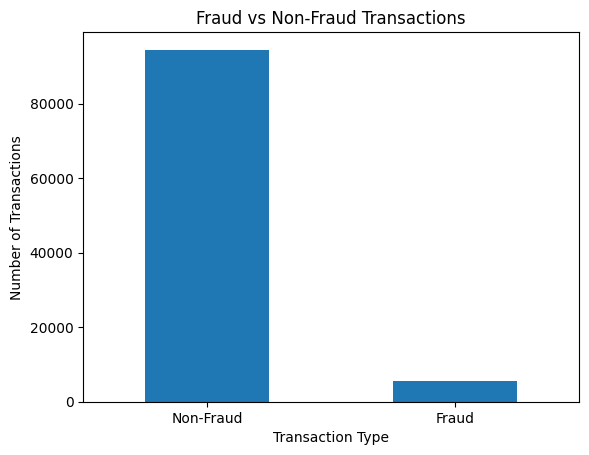

In [ ]:
# ============================================================
# STEP 9: FRAUD VS NON-FRAUD VISUALIZATION
# ============================================================


df['is_fraud'].value_counts().plot(kind='bar')

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ['Non-Fraud', 'Fraud'], rotation=0)

plt.show()

In [ ]:
print(df.columns.tolist())

['transaction_id', 'customer_id', 'transaction_date', 'transaction_time', 'hour_of_day', 'is_weekend', 'is_night_transaction', 'country', 'city', 'merchant_category', 'payment_method', 'device_type', 'customer_age', 'credit_score', 'account_age_years', 'account_balance', 'transaction_amount', 'num_prev_transactions', 'transaction_freq_monthly', 'distance_from_home_km', 'time_since_last_txn_hrs', 'is_international', 'failed_attempts', 'pin_changed_recently', 'is_fraud', 'fraud_type']


In [ ]:
# ============================================================
# STEP 10: CONVERT TRANSACTION DATE INTO FEATURES
# ============================================================

df['transaction_time'] = pd.to_datetime(
    df['transaction_time'],
    errors='coerce'
)

df['transaction_hour'] = df['transaction_time'].dt.hour

df = df.drop(columns=['transaction_time'])

In [ ]:
display(df.head())

,transaction_id,customer_id,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,device_type,...,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type,transaction_year,transaction_month,transaction_day,transaction_dayofweek,transaction_hour
0,TXN0000566049,CUST00194533,3,0,1,USA,New York,Gaming,Credit Card,Mobile,...,1,0,0,0,NaN,2022,9,5,0,3
1,TXN0000386372,CUST00155160,17,0,0,France,Los Angeles,ATM Withdrawal,Credit Card,Desktop,...,0,0,0,0,NaN,2024,4,17,2,17
2,TXN0000402702,CUST00005194,18,0,0,France,Berlin,Entertainment,Mobile Payment,Desktop,...,0,2,0,0,NaN,2021,8,19,3,18
3,TXN0000430256,CUST00173633,20,0,0,Germany,Delhi,Education,Credit Card,Mobile,...,1,0,0,0,NaN,2023,6,28,2,20
4,TXN0000107216,CUST00166557,18,1,0,UK,New York,Crypto Exchange,Cheque,POS Terminal,...,1,0,0,1,Phishing,2022,5,22,6,18


In [ ]:
# ============================================================
# STEP 12: REMOVE UNNECESSARY COLUMNS
# ============================================================

columns_to_drop = [
    'transaction_id',
    'customer_id',
    'fraud_type'
]

df = df.drop(
    columns=columns_to_drop,
    errors='ignore'
)

print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['hour_of_day', 'is_weekend', 'is_night_transaction', 'country', 'city', 'merchant_category', 'payment_method', 'device_type', 'customer_age', 'credit_score', 'account_age_years', 'account_balance', 'transaction_amount', 'num_prev_transactions', 'transaction_freq_monthly', 'distance_from_home_km', 'time_since_last_txn_hrs', 'is_international', 'failed_attempts', 'pin_changed_recently', 'is_fraud', 'transaction_year', 'transaction_month', 'transaction_day', 'transaction_dayofweek', 'transaction_hour']


In [ ]:
# ============================================================
# STEP 13: HANDLE MISSING VALUES
# ============================================================
numeric_columns = df.select_dtypes(
    include=np.number
).columns

for col in numeric_columns:
    df[col] = df[col].fillna(
        df[col].median()
    )

In [ ]:
categorical_columns = df.select_dtypes(
    include='object'
).columns

for col in categorical_columns:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

In [ ]:
print("Remaining missing values:")
print(df.isnull().sum().sum())

Remaining missing values:
0


In [ ]:
# ============================================================
# STEP 14: ENCODE CATEGORICAL VARIABLES
# ============================================================

categorical_columns = df.select_dtypes(
    include='object'
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['country', 'city', 'merchant_category', 'payment_method', 'device_type']


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

    label_encoders[col] = le

print("Categorical encoding completed!")

Categorical encoding completed!


In [ ]:
# ============================================================
# STEP 15: CHECK FINAL DATASET
# ============================================================

print("Final dataset shape:")
print(df.shape)

display(df.head())

Final dataset shape:
(100000, 26)


,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,device_type,customer_age,credit_score,...,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,transaction_year,transaction_month,transaction_day,transaction_dayofweek,transaction_hour
0,3,0,1,9,11,7,2,2,29,663,...,17.43,1,0,0,0,2022,9,5,0,3
1,17,0,0,3,4,0,2,1,55,629,...,0.65,0,0,0,0,2024,4,17,2,17
2,18,0,0,3,0,5,5,1,61,677,...,10.13,0,2,0,0,2021,8,19,3,18
3,20,0,0,4,1,3,2,2,50,592,...,4.51,1,0,0,0,2023,6,28,2,20
4,18,1,0,8,11,2,1,3,51,783,...,10.71,1,0,0,1,2022,5,22,6,18


In [ ]:
print(df.dtypes)

hour_of_day                   int64
is_weekend                    int64
is_night_transaction          int64
country                       int64
city                          int64
merchant_category             int64
payment_method                int64
device_type                   int64
customer_age                  int64
credit_score                  int64
account_age_years           float64
account_balance             float64
transaction_amount          float64
num_prev_transactions         int64
transaction_freq_monthly      int64
distance_from_home_km       float64
time_since_last_txn_hrs     float64
is_international              int64
failed_attempts               int64
pin_changed_recently          int64
is_fraud                      int64
transaction_year              int32
transaction_month             int32
transaction_day               int32
transaction_dayofweek         int32
transaction_hour              int32
dtype: object


In [ ]:
# ============================================================
# STEP 16: CREATE FEATURES (X) AND TARGET (Y)
# ============================================================

X = df.drop(
    columns=['is_fraud']
)

y = df['is_fraud']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000, 25)
y shape: (100000,)


In [ ]:
# ============================================================
# STEP 17: SPLIT DATA INTO TRAINING AND TESTING
# ===============================================


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (80000, 25)
Testing data: (20000, 25)


In [ ]:
# ============================================================
# STEP 18: FEATURE SCALING
# ============================================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Feature scaling completed!")

Feature scaling completed!


In [ ]:
# ============================================================
# STEP 19: LOGISTIC REGRESSION MODEL
# ============================================================

logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

print("Training Logistic Regression...")

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression training completed!")

Training Logistic Regression...
Logistic Regression training completed!


In [ ]:
# ============================================================
# STEP 20: LOGISTIC REGRESSION PREDICTION
# ============================================================

y_pred_lr = logistic_model.predict(
    X_test_scaled
)

y_prob_lr = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

In [ ]:
# ============================================================
# STEP 21: LOGISTIC REGRESSION RESULTS
# ============================================================

print("========== LOGISTIC REGRESSION ==========")

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Precision:",
      precision_score(y_test, y_pred_lr))

print("Recall:",
      recall_score(y_test, y_pred_lr))

print("F1 Score:",
      f1_score(y_test, y_pred_lr))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

========== LOGISTIC REGRESSION ==========
Accuracy: 0.67095
Precision: 0.09794419970631424
Recall: 0.6036199095022624
F1 Score: 0.16854074542008843
ROC-AUC: 0.7048975344814581

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.67      0.79     18895
           1       0.10      0.60      0.17      1105

    accuracy                           0.67     20000
   macro avg       0.53      0.64      0.48     20000
weighted avg       0.92      0.67      0.76     20000



In [ ]:
# ============================================================
# STEP 22: RANDOM FOREST MODEL
# ============================================================

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

print("Training Random Forest...")

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed!")

Training Random Forest...
Random Forest training completed!


In [ ]:
# ============================================================
# STEP 23: RANDOM FOREST PREDICTION
# ============================================================

y_pred_rf = random_forest_model.predict(
    X_test
)

y_prob_rf = random_forest_model.predict_proba(
    X_test
)[:, 1]

In [ ]:
# ============================================================
# STEP 24: RANDOM FOREST RESULTS
# ============================================================


print("========== RANDOM FOREST ==========")

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

========== RANDOM FOREST ==========
Accuracy: 0.94475
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.6758193350008801

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     18895
           1       0.00      0.00      0.00      1105

    accuracy                           0.94     20000
   macro avg       0.47      0.50      0.49     20000
weighted avg       0.89      0.94      0.92     20000



In [ ]:
# ============================================================
# STEP 25: RANDOM FOREST CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm)

[[18895     0]
 [ 1105     0]]


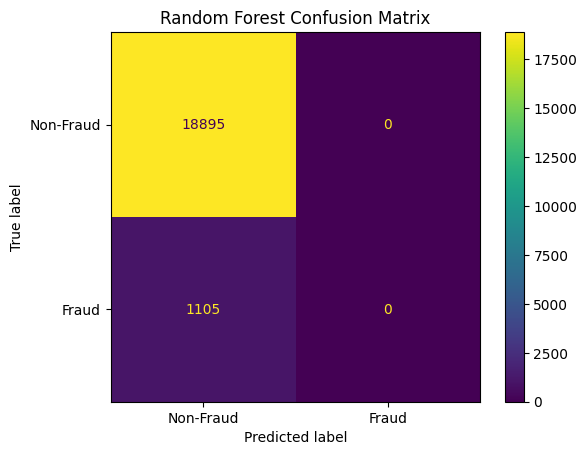

In [ ]:
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-Fraud', 'Fraud']
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

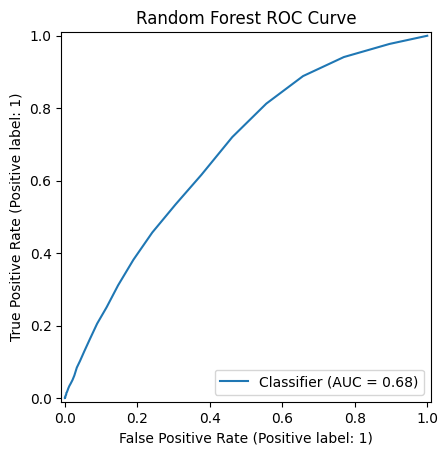

In [ ]:
# ============================================================
# STEP 26: RANDOM FOREST ROC CURVE
# ============================================================

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf
)

plt.title("Random Forest ROC Curve")
plt.show()

In [ ]:
# ============================================================
# STEP 27: COMPARE ALL MODELS
# ============================================================
results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

display(results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.67095,0.097944,0.60362,0.168541,0.704898
1,Random Forest,0.94475,0.000000,0.00000,0.000000,0.675819


In [ ]:
# ============================================================
# STEP 29: FIND BEST MODEL
# ============================================================

best_model_name = results.loc[
    results['F1 Score'].idxmax(),
    'Model'
]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [ ]:
# ============================================================
# STEP 30: RANDOM FOREST FEATURE IMPORTANCE
# ============================================================
feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
        random_forest_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

display(
    feature_importance.head(15)
)

,Feature,Importance
16,time_since_last_txn_hrs,0.068760
12,transaction_amount,0.064538
11,account_balance,0.062933
9,credit_score,0.062430
18,failed_attempts,0.061954
15,distance_from_home_km,0.058993
10,account_age_years,0.055437
13,num_prev_transactions,0.052524
8,customer_age,0.051000
5,merchant_category,0.048953


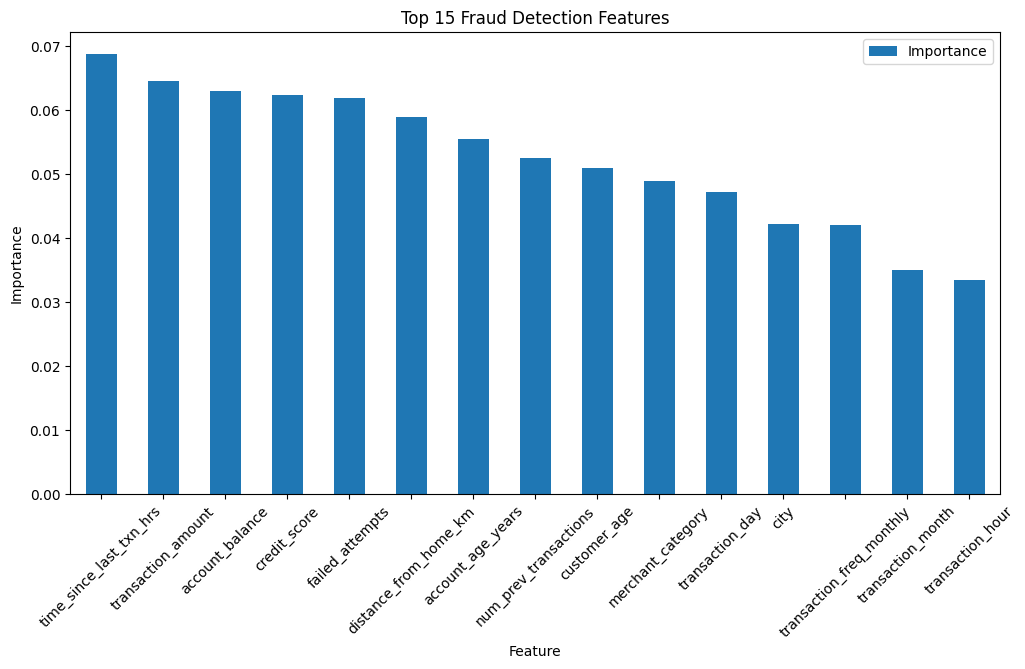

In [ ]:
# ============================================================
# STEP 31: TOP 15 IMPORTANT FEATURES GRAPH
# ============================================================

feature_importance.head(15).plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(12, 6)
)

plt.title("Top 15 Fraud Detection Features")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.show()

In [ ]:
# ============================================================
# STEP 32: TEST A NEW TRANSACTION
# ============================================================

new_transaction = X_test.iloc[
    [0]
].copy()

display(new_transaction)

,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,device_type,customer_age,credit_score,...,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,transaction_year,transaction_month,transaction_day,transaction_dayofweek,transaction_hour
64539,11,0,0,9,12,0,2,2,34,630,...,5.9,8.83,0,0,0,2021,10,15,4,11


In [ ]:
# ============================================================
# STEP 33: PREDICT NEW TRANSACTION
# ============================================================

new_prediction = random_forest_model.predict(
    new_transaction
)

new_probability = random_forest_model.predict_proba(
    new_transaction
)[0][1]

if new_prediction[0] == 1:

    print("🚨 FRAUD TRANSACTION DETECTED")

else:

    print("✅ TRANSACTION IS NOT FRAUD")

print(
    "Fraud Probability:",
    round(new_probability * 100, 2),
    "%"
)

✅ TRANSACTION IS NOT FRAUD
Fraud Probability: 5.0 %


In [ ]:
# ============================================================
# STEP 34: SAVE THE MODEL
# ============================================================

import joblib

joblib.dump(
    random_forest_model,
    'bank_fraud_model.pkl'
)

joblib.dump(
    label_encoders,
    'label_encoders.pkl'
)

joblib.dump(
    scaler,
    'scaler.pkl'
)

print("All model files saved successfully!")

All model files saved successfully!


In [ ]:
from google.colab import files

files.download(
    'bank_fraud_model.pkl'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>